In [ ]:
from google.colab import drive  # pyright: ignore[reportMissingImports]
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
# Format floating-point numbers
pd.options.display.float_format = '{:.2f}'.format
drive.mount('/content/drive', force_remount=True)
PATH = '/content/drive/MyDrive/Applied Statistics/Datasets/'

In [5]:
df = pd.read_csv(PATH + 'student_profiles.csv')
df

,study_hours,sleep_hours,lecture_attendance,notes_pages_per_week,screen_time,social_media_minutes,coffee_per_day,stress_score,exercise_hours,commute_minutes,part_time_work_hours,past_exam_average,engagement_index,early_classes_per_week
0,12.03,6.05,61.32,42.55,6.64,188.20,1.73,7.43,1.78,68.91,26.85,23.13,22.54,4
1,10.00,7.36,59.03,29.78,7.27,187.01,1.05,6.54,2.49,45.70,15.64,22.65,21.63,3
2,12.44,7.16,77.64,36.26,6.58,219.18,1.88,4.06,1.63,2.00,0.00,24.57,23.76,0
3,13.34,6.21,58.79,41.18,6.37,176.30,1.75,4.94,2.42,28.36,8.43,24.42,21.69,2
4,16.83,6.29,76.95,25.47,4.09,141.86,2.59,6.48,1.11,24.97,16.56,22.23,30.58,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,22.91,7.56,68.77,44.42,4.00,188.27,1.79,4.18,3.35,22.50,3.20,26.42,31.89,1
146,11.33,6.11,57.96,44.29,7.85,258.14,2.73,7.23,0.93,52.33,10.62,21.43,17.37,3
147,20.47,6.03,78.51,50.35,5.81,186.70,3.14,7.18,1.61,78.99,16.63,23.79,33.81,5
148,18.06,7.11,40.13,40.29,7.11,209.23,2.19,6.57,1.89,2.00,6.58,22.03,19.99,3


In [7]:
variables = ["study_hours", "sleep_hours", "lecture_attendance", "notes_pages_per_week", "screen_time", "social_media_minutes", "coffee_per_day",
             "stress_score", "exercise_hours", "commute_minutes", "part_time_work_hours", "past_exam_average", "engagement_index", "early_classes_per_week"]

In [ ]:
df[variables].describe().to_excel("summary.xlsx", index=True)
df[variables].describe()

,study_hours,sleep_hours,lecture_attendance,notes_pages_per_week,screen_time,social_media_minutes,coffee_per_day,stress_score,exercise_hours,commute_minutes,part_time_work_hours,past_exam_average,engagement_index,early_classes_per_week
count,150.00,150.00,150.00,150.00,150.00,150.00,150.00,150.00,150.00,150.00,150.00,150.00,150.00,150.00
mean,19.02,6.83,71.54,44.38,5.65,162.57,2.09,5.70,2.41,30.97,10.14,24.39,27.39,1.95
std,5.66,0.66,13.10,13.39,1.40,57.84,0.58,1.34,1.01,21.46,4.93,2.07,7.96,1.56
min,5.76,5.36,38.14,15.66,2.33,20.00,0.75,1.77,0.00,2.00,0.00,19.14,10.00,0.00
25%,14.73,6.37,62.29,34.37,4.63,124.23,1.68,4.87,1.72,14.77,6.85,22.95,22.04,1.00
50%,18.56,6.83,71.29,43.69,5.66,159.46,2.14,5.74,2.38,26.53,10.17,24.24,26.34,2.00
75%,22.93,7.30,81.25,53.53,6.48,196.40,2.55,6.74,3.09,43.42,13.27,25.74,32.62,3.00
max,35.00,8.61,100.00,78.80,10.80,337.98,3.27,8.49,5.65,105.00,26.85,30.00,49.44,6.00


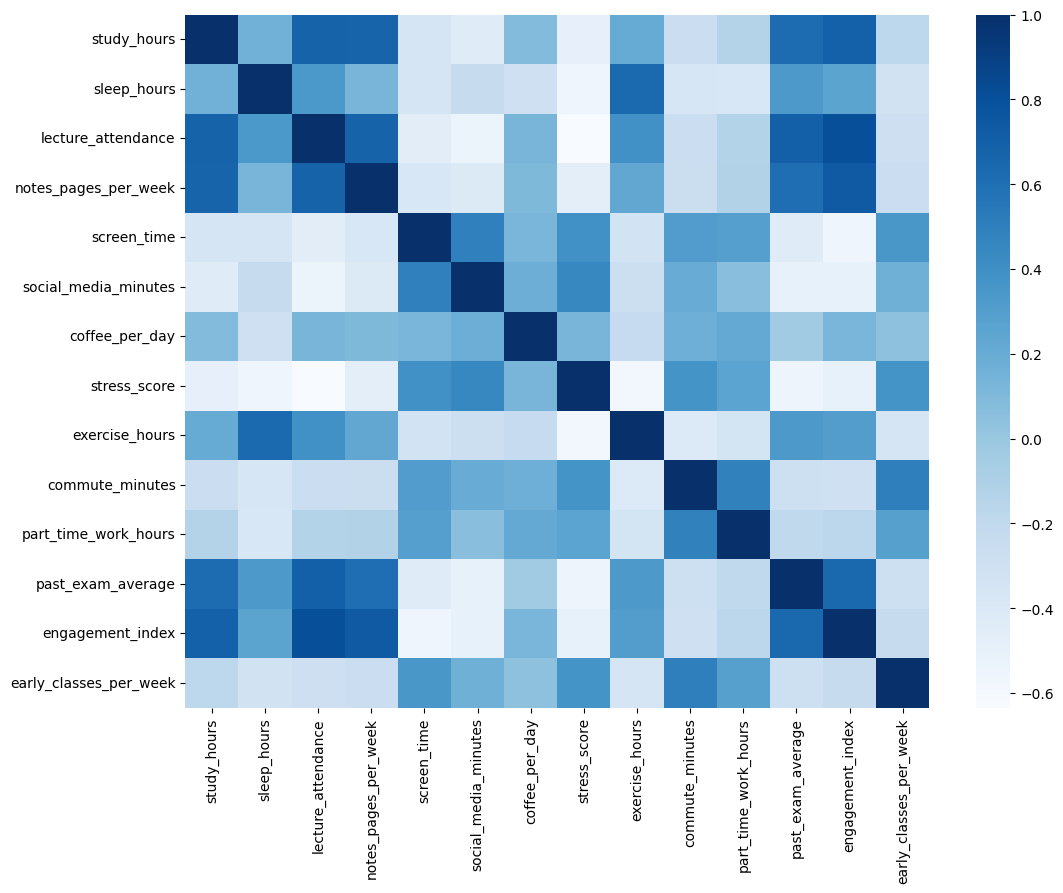

In [25]:
import seaborn as sns
corrmat = df[variables].corr()
plt.figure(figsize=(12, 9))
sns.heatmap(corrmat, cmap="Blues", annot=False)
plt.savefig("correlation_matrix.png")

In [ ]:
from sklearn.preprocessing import StandardScaler
# Preprocessing
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(
    df[variables]), columns=df[variables].columns, index=df[variables].index)

In [ ]:
# PCA
from sklearn.decomposition import PCA

pca = PCA(random_state=33)
scores = pca.fit_transform(X)
print('PCA explained variance ratio:\n',
      pca.explained_variance_ratio_)

PCA explained variance ratio:
 [0.41696783 0.15246057 0.0781986  0.06412023 0.05313602 0.0468835
 0.0339533  0.03081605 0.02769862 0.02551264 0.02151229 0.02043595
 0.01806887 0.01023552]


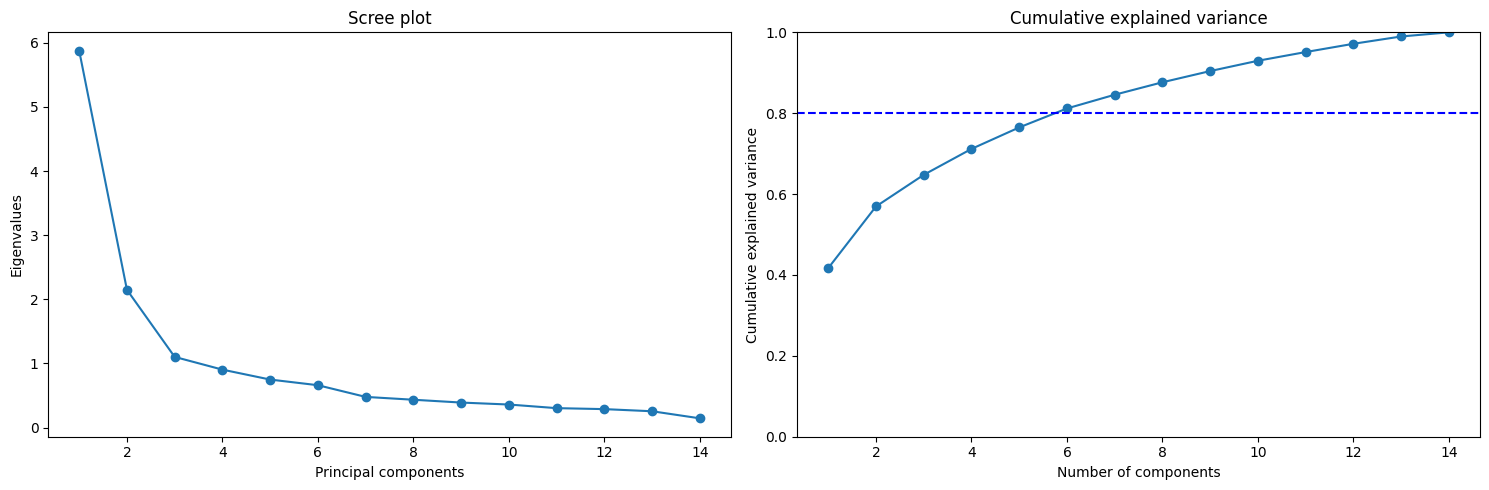

In [ ]:
import numpy as np
n, p = X.shape

fig, axs = plt.subplots(1, 2, figsize=(15, 5))
axs[0].plot(np.arange(1, p+1),
            pca.explained_variance_, marker='o')
axs[0].set_title('Scree plot')
axs[0].set_xlabel('Principal components')
axs[0].set_ylabel('Eigenvalues')

cum_explained = np.cumsum(pca.explained_variance_ratio_)

axs[1].plot(np.arange(1, p+1), cum_explained, marker='o')
axs[1].axhline(0.8, color='blue', linestyle='--')
axs[1].set_xlabel('Number of components')
axs[1].set_ylabel('Cumulative explained variance')
axs[1].set_title('Cumulative explained variance')
axs[1].set_ylim(0, 1)
plt.tight_layout()
plt.savefig("scree_plot.png")
plt.show()

In [19]:
loadings = pca.components_.T

/tmp/ipykernel_1195/252032652.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(X.columns, rotation=90)
/tmp/ipykernel_1195/252032652.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(X.columns, rotation=90)


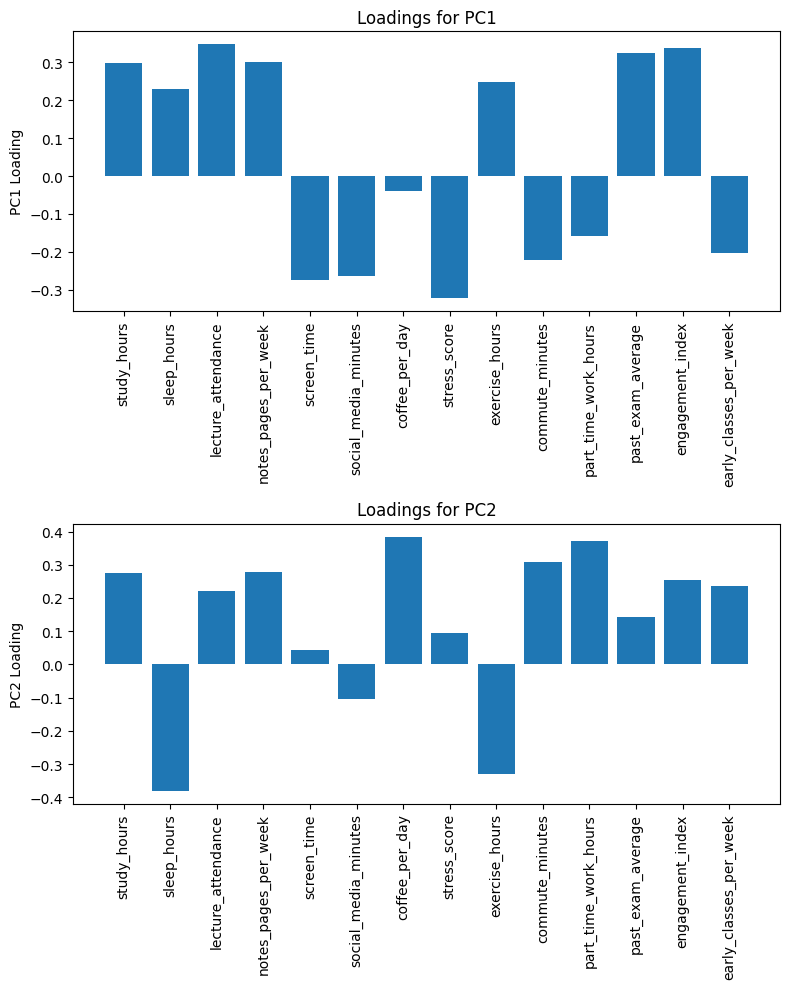

In [26]:
fig, axes = plt.subplots(2, 1, figsize=(8, 10))

for i, ax in enumerate(axes):
    ax.bar(X.columns, loadings[:, i])
    ax.set_xticklabels(X.columns, rotation=90)
    ax.set_ylabel(f"PC{i+1} Loading")
    ax.set_title(f"Loadings for PC{i+1}")

plt.tight_layout()
plt.savefig("loadings.png")
plt.show()

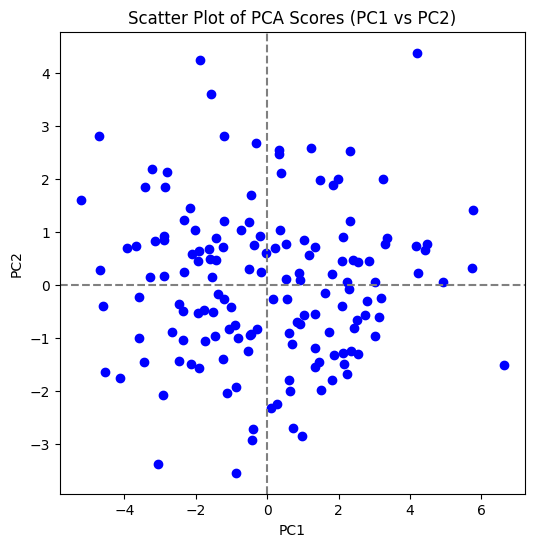

In [31]:
scores = pca.transform(X)
n = scores.shape[0]

# Scatter plot of the scores for the first two PCs
plt.figure(figsize=(6, 6))
plt.scatter(scores[:, 0],
            scores[:, 1], color="blue", marker='o')
plt.axhline(0, linestyle='--', color='grey')
plt.axvline(0, linestyle='--', color='grey')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Scatter Plot of PCA Scores (PC1 vs PC2)")
plt.savefig("PCA_plot")
plt.show()

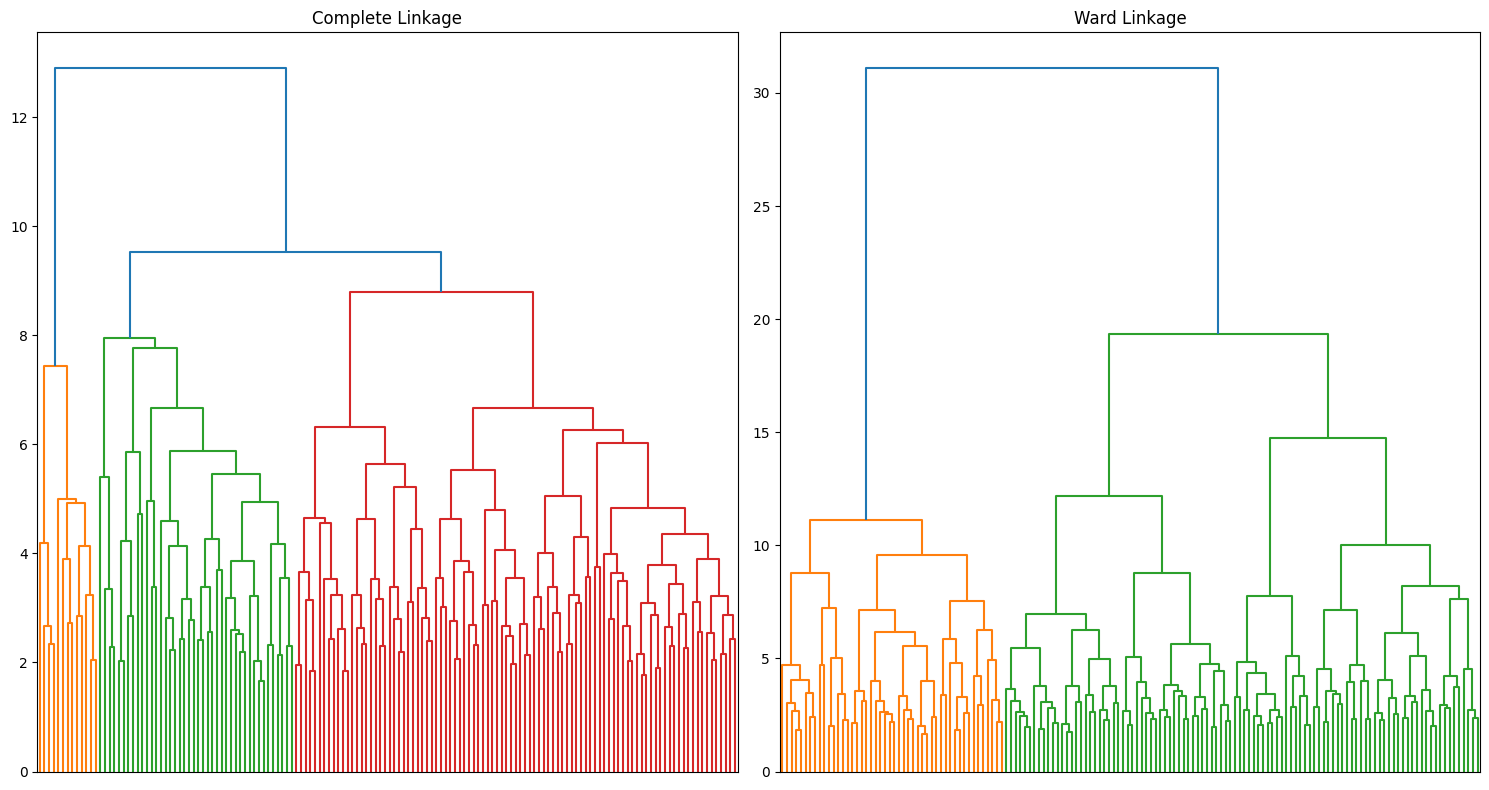

In [ ]:
# Clustering
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import dendrogram, linkage

D = pdist(X, metric='euclidean')
hc_ward = linkage(D, method='ward')
hc_complete = linkage(D, method='complete')

fig, axs = plt.subplots(1, 2, figsize=(15, 8))
axs = axs.flatten()

dendrogram(hc_complete, ax=axs[0], no_labels=True)
axs[0].set_title("Complete Linkage")

dendrogram(hc_ward, ax=axs[1], no_labels=True)
axs[1].set_title("Ward Linkage")

plt.tight_layout()
plt.savefig("dendrogram.png")
plt.show()